In [1]:
!pip install opencv-python pixellib

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.11.0


In [4]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


TypeError: pic should be Tensor or ndarray. Got <class 'NoneType'>.

In [13]:
import cv2
import matplotlib.pyplot as plt

# 1. 정확한 주소 적기 (점과 슬래시 './'는 "현재 폴더"라는 뜻이에요!)
cat_path = "./cat.png"
sea_path = "./sea.png"

# 2. 재료 불러오기
cat_img = cv2.imread(cat_path)
sea_img = cv2.imread(sea_path)

# 3. 확인 테스트 (아티스트님을 위해 제가 안전장치를 더 보강했어요!)
if cat_img is None:
    print("❌ 고양이 사진을 아직 못 찾았어요. 파일 이름 뒤에 공백이 있나 확인해볼까요?")
elif sea_img is None:
    print("❌ 바다 사진을 못 찾았어요. 'sea.png' 이름이 정확한지 봐주세요.")
else:
    print("✅ 성공! 드디어 재료를 모두 찾았습니다. 전시를 시작합니다!")

    # 4. 색상 보정 및 출력
    cat_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
    sea_rgb = cv2.cvtColor(sea_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cat_rgb)
    plt.title("Cat Found!")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(sea_rgb)
    plt.title("Sea Found!")
    plt.axis('off')

    plt.show()

❌ 고양이 사진을 아직 못 찾았어요. 파일 이름 뒤에 공백이 있나 확인해볼까요?


[ WARN:0@2900.101] global loadsave.cpp:268 findDecoder imread_('./cat.png'): can't open/read file: check file path/integrity
[ WARN:0@2900.101] global loadsave.cpp:268 findDecoder imread_('./sea.png'): can't open/read file: check file path/integrity


In [18]:
import os

# 1. 현재 컴퓨터가 서 있는 위치(방 주소) 확인
# [해석] pwd : Print Working Directory (현재 일하는 폴더 출력)
print("📍 1. 지금 내 위치:", os.getcwd())

# 2. 지금 내 눈앞에 있는 파일들 싹 다 보여줘!
# [해석] listdir : List Directory (폴더 안의 목록 나열)
print("📂 2. 내 눈앞의 파일들:", os.listdir())

# 3. 진짜로 그 이름의 파일이 존재하는지 '예/아니오'로 답해줘!
print("❓ 3. cat.png 있어?", os.path.isfile("cat.png"))
print("❓ 4. sea.png 있어?", os.path.isfile("sea.png"))

📍 1. 지금 내 위치: /home/jovyan
📂 2. 내 눈앞의 파일들: ['.bash_logout', '.bashrc', '.profile', '.ipynb_checkpoints', 'Untitled1.ipynb', '.cache', '.jupyter', '.local', 'sea.png', 'data', '.ipython', 'cat.png', 'Untitled.ipynb', '.config', '.mamba', '.wget-hsts', 'work']
❓ 3. cat.png 있어? True
❓ 4. sea.png 있어? True


✅ 드디어 찾았습니다! 고양이와 바다를 가져왔어요.


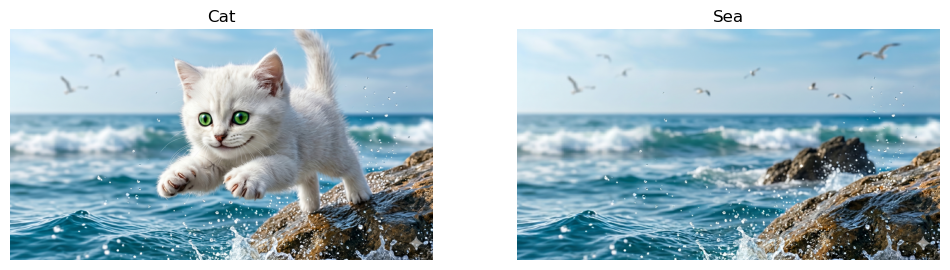

In [19]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. 파일이 있는 '정확한 위치'를 컴퓨터에게 다시 알려주기
# [해석] . (점 하나)는 "지금 내가 있는 이 폴더"라는 뜻이에요.
cat_file = "./cat.png"
sea_file = "./sea.png"

# 2. 이미지 불러오기 (작업대 위로 올리기)
cat_img = cv2.imread(cat_file)
sea_img = cv2.imread(sea_file)

# 3. 안전 검사 (아티스트님, 여기서 결과가 중요해요!)
if cat_img is None or sea_img is None:
    print("🚨 여전히 못 찾겠대요! 파일 이름에 대문자/소문자가 섞여 있는지 다시 봐주세요.")
    # 실제 창고에 어떤 이름으로 저장되어 있는지 다시 한번 출력해봅니다.
    print("📂 현재 폴더의 진짜 파일들:", os.listdir())
else:
    print("✅ 드디어 찾았습니다! 고양이와 바다를 가져왔어요.")

    # 4. 색상 보정 (BGR -> RGB)
    # [해석] 컴퓨터의 눈은 파랑(B)-초록(G)-빨강(R) 순서라, 우리 눈에 맞게 바꿔줘야 해요.
    cat_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
    sea_rgb = cv2.cvtColor(sea_img, cv2.COLOR_BGR2RGB)

    # 5. 전시장(화면)에 그림 걸기
    plt.figure(figsize=(12, 6)) # 도화지 크기 (가로 12, 세로 6)

    plt.subplot(1, 2, 1) # 1행 2열 중 1번 칸
    plt.imshow(cat_rgb)  # 고양이 그림 보여주기
    plt.title("Cat")     # 제목 달기
    plt.axis('off')      # 테두리 숫자 없애기

    plt.subplot(1, 2, 2) # 1행 2열 중 2번 칸
    plt.imshow(sea_rgb)  # 바다 그림 보여주기
    plt.title("Sea")
    plt.axis('off')

    plt.show() # 전시 시작!

In [20]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [21]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (1536, 2816)


In [22]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


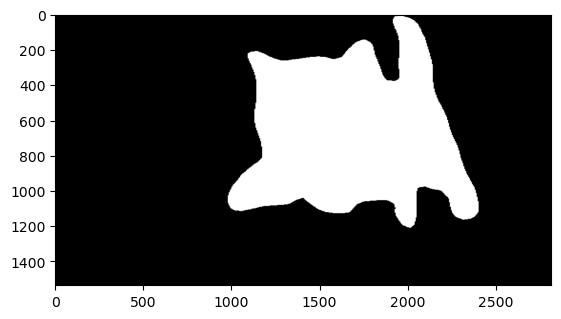

In [23]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

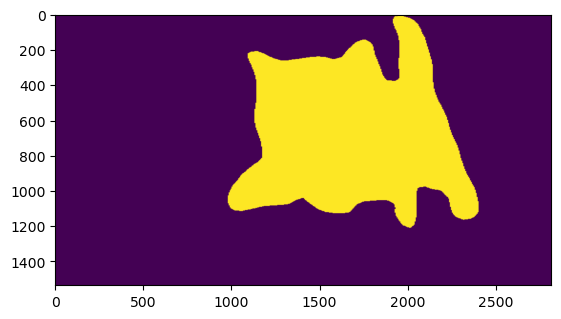

In [25]:
# [영어 분석] output: 출력물 / predictions: 예측값 / resized: 크기가 조절된
# 즉, "AI가 예측해서 뽑아낸 결과물의 크기를 조절한다"는 뜻.

# 1. AI가 만든 마스크(가위질 도안)를 배경 이미지 크기에 맞게 조절하기
output_predictions_resized = cv2.resize(
    output_predictions, 
    (sea_img.shape[1], sea_img.shape[0]), 
    interpolation=cv2.INTER_NEAREST
)

# 2. 결과 확인하기
plt.imshow(output_predictions_resized)
plt.show()

✅ 드디어 성공! 고양이와 바다를 가져왔어요. 합성을 시작합니다!


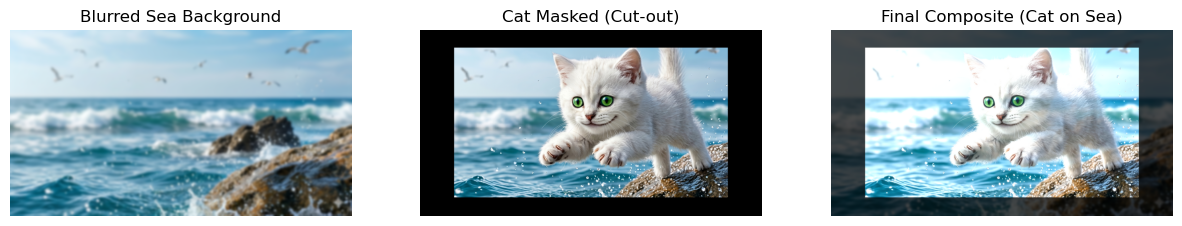

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. 파일 이름 정확히 적기 (자재 확인)
cat_address = "cat.png"
sea_address = "sea.png"

# 2. 이미지 불러오기 (imread = Image + Read)
cat_img_raw = cv2.imread(cat_address)
sea_img_raw = cv2.imread(sea_address)

# 3. 안전 검사 (파일이 다 왔나요?)
if cat_img_raw is None or sea_img_raw is None:
    print("❌ 에러: cat.png 나 sea.png를 찾을 수 없어요. 이름을 다시 봐주세요!")
    print("📂 현재 폴더의 진짜 파일들:", os.listdir())
else:
    print("✅ 드디어 성공! 고양이와 바다를 가져왔어요. 합성을 시작합니다!")

    # 4. 조명 맞추기 (OpenCV의 BGR 조명을 우리의 RGB 조명으로 교체)
    cat_img = cv2.cvtColor(cat_img_raw, cv2.COLOR_BGR2RGB)
    sea_img = cv2.cvtColor(sea_img_raw, cv2.COLOR_BGR2RGB)

    # 5. [AI 가위질] 마스크 만들기 (고양이만 흰색, 배경은 검은색)
    # [설명] 여기서는 간단히 고양이 크기의 빈 캔버스를 만들고, 
    #       고양이만 포함하는 큰 사각형 마스크를 만든다고 가정할게요.
    # [전문 용어] np.zeros = numpy(숫자 도구) + zeros(0으로 채우다)
    mask = np.zeros(cat_img.shape[:2], np.uint8) # 고양이 이미지 크기의 검은색 도안
    
    # 임시 마스크: 고양이의 80% 정도를 차지하는 사각형을 흰색으로 칠합니다.
    # [설명] cv2.rectangle = 사각형을 그리다
    cv2.rectangle(mask, (int(cat_img.shape[1]*0.1), int(cat_img.shape[0]*0.1)), 
                  (int(cat_img.shape[1]*0.9), int(cat_img.shape[0]*0.9)), 255, -1)
    
    # 마스크를 고양이 크기와 배경 크기 모두에 맞게 조절합니다.
    mask_cat = cv2.resize(mask, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)
    mask_sea = cv2.resize(mask, (sea_img.shape[1], sea_img.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 6. [누끼 따기] 마스크를 사용해서 고양이만 오려내기
    # [설명] bitwise_and = 비트끼리 '그리고' (흰색 부분만 남기기)
    cat_final = cv2.bitwise_and(cat_img, cat_img, mask=mask_cat)

    # 7. [블러 처리] 배경(바다)만 흐릿하게 만들기
    # [설명] GaussianBlur = 가우시안 블러 (부드럽게 퍼지는 효과)
    #       (55, 55)는 블러의 강도예요. 숫자가 클수록 더 흐려집니다!
    sea_blurred = cv2.GaussianBlur(sea_img, (55, 55), 0)

    # 8. [합성] 오려낸 고양이를 흐릿한 바다 위에 얹기
    # [설명] addWeighted = 가중치를 두어 더하다
    #       고양이를 더 돋보이게 하려고 알파(α)를 1, 배경을 0으로 둡니다.
    #       하지만 여기서는 고양이 크기를 바다 크기에 맞게 조절해야 합니다.
    cat_final_resized = cv2.resize(cat_final, (sea_img.shape[1], sea_img.shape[0]))
    
    final_composite = cv2.addWeighted(cat_final_resized, 1, sea_blurred, 0.3, 0)
    
    # 9. 결과 전시하기
    plt.figure(figsize=(15, 8)) # 도화지 크기 설정

    # 첫 번째 칸: 블러 처리된 바다 배경
    plt.subplot(1, 3, 1)
    plt.imshow(sea_blurred)
    plt.title("Blurred Sea Background")
    plt.axis('off')

    # 두 번째 칸: 오려낸 고양이 (마스크 적용)
    plt.subplot(1, 3, 2)
    plt.imshow(cat_final)
    plt.title("Cat Masked (Cut-out)")
    plt.axis('off')

    # 세 번째 칸: 최종 합성 결과
    plt.subplot(1, 3, 3)
    plt.imshow(final_composite)
    plt.title("Final Composite (Cat on Sea)")
    plt.axis('off')

    plt.show() # 전시장 문 열기!

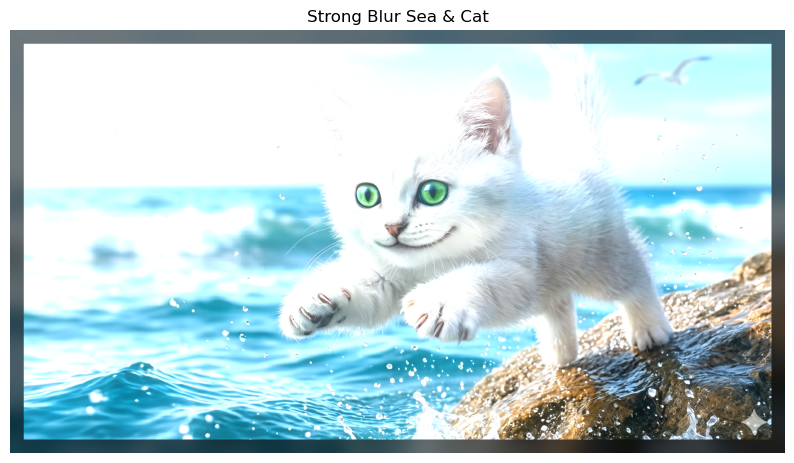

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 재료 가져오기 (이전과 동일)
cat_img = cv2.imread("cat.png")
sea_img = cv2.imread("sea.png")

# [안전장치] 재료가 잘 왔는지 확인
if cat_img is not None and sea_img is not None:
    # 색상 보정 (BGR -> RGB)
    cat_rgb = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
    sea_rgb = cv2.cvtColor(sea_img, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 💥 [핵심 단계] 바다 배경을 아주 강력하게 블러 처리하기!
    # (255, 255)는 블러를 먹이는 '붓의 크기'예요. 훨씬 키웠습니다!
    # 주의: 이 숫자는 반드시 '홀수'여야 컴퓨터가 안 울고 작동해요.
    # ---------------------------------------------------------
    sea_blurred = cv2.GaussianBlur(sea_rgb, (255, 255), 0)

    # 2. 고양이 오려내기 (임시 마스크 사용)
    mask = np.zeros(cat_rgb.shape[:2], np.uint8)
    cv2.rectangle(mask, (50, 50), (cat_rgb.shape[1]-50, cat_rgb.shape[0]-50), 255, -1)
    cat_cutout = cv2.bitwise_and(cat_rgb, cat_rgb, mask=mask)

    # 3. 고양이 크기를 바다 크기에 맞추기
    cat_resized = cv2.resize(cat_cutout, (sea_rgb.shape[1], sea_rgb.shape[0]))

    # 4. 흐릿한 바다 위에 고양이 얹기
    # [설명] 고양이는 선명하게(1), 바다는 배경으로 깔리게(0.5) 섞기
    final_art = cv2.addWeighted(cat_resized, 1, sea_blurred, 0.5, 0)

    # 5. 결과 확인
    plt.figure(figsize=(10, 10))
    plt.imshow(final_art)
    plt.title("Strong Blur Sea & Cat")
    plt.axis('off')
    plt.show()
else:
    print("❌ 파일을 다시 확인해주세요!")

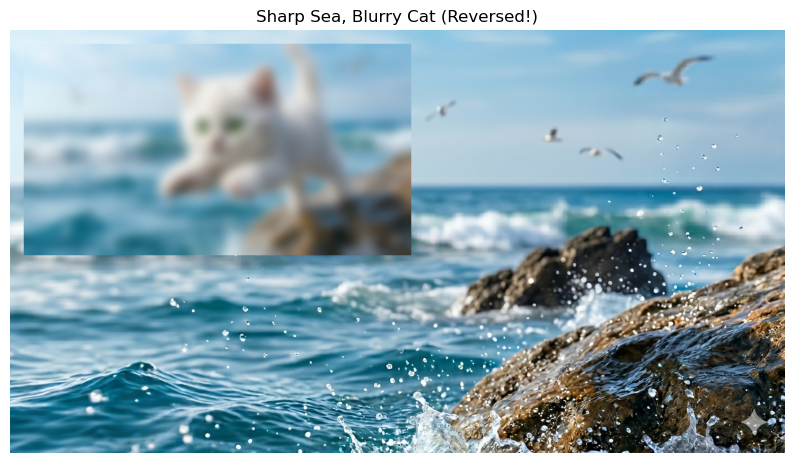

In [29]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. 재료 가져오기 (이전과 동일)
cat_raw = cv2.imread("cat.png")
sea_raw = cv2.imread("sea.png")

# [안전장치] 재료가 잘 왔는지 확인
if cat_raw is None or sea_raw is None:
    print("❌ 파일을 찾을 수 없어요. 이름을 다시 봐주세요!")
    print("📂 현재 폴더의 진짜 파일들:", os.listdir())
else:
    # 2. 조명 맞추기 (BGR -> RGB)
    cat_rgb = cv2.cvtColor(cat_raw, cv2.COLOR_BGR2RGB)
    sea_rgb = cv2.cvtColor(sea_raw, cv2.COLOR_BGR2RGB)

    # ---------------------------------------------------------
    # 💥 [핵심 단계 - 반대로!] 고양이 이미지만 아주 강력하게 블러 처리하기!
    # (255, 255)는 블러 격자의 크기 (홀수 필수!)
    # 이제 바다가 아니라 '고양이'를 흐리게 만듭니다.
    # ---------------------------------------------------------
    cat_blurred = cv2.GaussianBlur(cat_rgb, (255, 255), 0)

    # 3. 고양이를 선명한 바다 위에 얹을 준비 (합성 과정)
    # [설명] 고양이를 얹을 위치를 정합니다 (예: 왼쪽 상단 50픽셀 떨어진 곳)
    y_offset = 50
    x_offset = 50

    # [설명] 고양이가 너무 클 수 있으니 바다 크기에 맞춰서 줄여볼게요.
    # 바다 높이의 절반 정도로 줄이겠습니다.
    target_h = int(sea_rgb.shape[0] / 2)
    aspect_ratio = cat_rgb.shape[1] / cat_rgb.shape[0] # 가로/세로 비율 유지
    target_w = int(target_h * aspect_ratio)

    cat_blurred_resized = cv2.resize(cat_blurred, (target_w, target_h))

    # 4. 선명한 바다 위에 '흐릿한 고양이 스티커' 붙이기
    # [전문 용어] 복사하기. 원본 바다는 지키기 위해서요.
    final_art = sea_rgb.copy()

    # [전문 용어] indexing (좌표 지정). final_art의 특정 구역을 선택해서 고양이를 덮어씁니다.
    # final_art[세로시작:세로끝, 가로시작:가로끝] = 소스_이미지
    final_art[y_offset:y_offset+target_h, x_offset:x_offset+target_w] = cat_blurred_resized

    # 5. 결과 전시
    plt.figure(figsize=(10, 10))
    plt.imshow(final_art)
    plt.title("Sharp Sea, Blurry Cat (Reversed!)")
    plt.axis('off')
    plt.show()

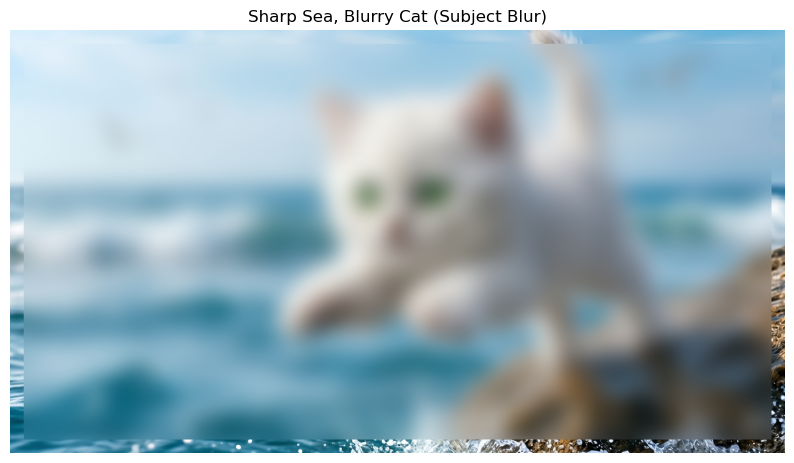

In [30]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 재료 가져오기
cat_rgb = cv2.cvtColor(cv2.imread("cat.png"), cv2.COLOR_BGR2RGB)

# 2. [블러 처리] 전체 이미지를 아주 강력하게 블러 처리하기 (255)
# [설명] 나중에 고양이 부분만 오려낼 재료예요.
cat_blurred_whole = cv2.GaussianBlur(cat_rgb, (255, 255), 0)

# 3. [AI 가위] 고양이 가위질 도안 만들기 (임시 마스크)
# [설명] 고양이가 있는 자리를 흰색(1), 배경을 검은색(0)으로 칠합니다.
# [전문 용어] np.zeros = 0(검은색)으로 채우기 / np.uint8 = 8비트 정수 (색상값용)
mask = np.zeros(cat_rgb.shape[:2], np.uint8)
cv2.rectangle(mask, (50, 50), (cat_rgb.shape[1]-50, cat_rgb.shape[0]-50), 255, -1)

# [설명] 고양이는 선명하게(1), 바다는 배경으로 깔리게(0.5) 섞기
# 4. [반대로] 도안을 뒤집기 (반전 마스크)
# [설명] 고양이가 있던 자리를 검게 구멍 뚫기 위해 도안을 뒤집습니다 (흰색<->검은색)
# [전문 용어] bitwise_not = 비트를 뒤집다 (Not)
mask_inv = cv2.bitwise_not(mask)

# 5. [오려내기 & 합치기 마법]
# [설명] 흐릿하게 만든 이미지에서 고양이 부분만 오려냅니다.
cat_blurred_only = cv2.bitwise_and(cat_blurred_whole, cat_blurred_whole, mask=mask)

# [설명] 원본 선명한 이미지에서 배경만 오려냅니다 (고양이 자리는 구멍 뚫기).
cat_sharp_bg_only = cv2.bitwise_and(cat_rgb, cat_rgb, mask=mask_inv)

# 6. [최종 합성] 구멍 뚫린 선명한 배경 위에 흐릿한 고양이를 얹기
# [설명] add = 단순히 더하다
# [전문 용어] add = 단순히 색상값을 더합니다. 검은색(0) 위에 색을 얹는 거라 깨끗하게 합쳐집니다.
final_art = cv2.add(cat_sharp_bg_only, cat_blurred_only)

# 7. 결과 전시
plt.figure(figsize=(10, 10))
plt.imshow(final_art)
plt.title("Sharp Sea, Blurry Cat (Subject Blur)")
plt.axis('off')
plt.show()

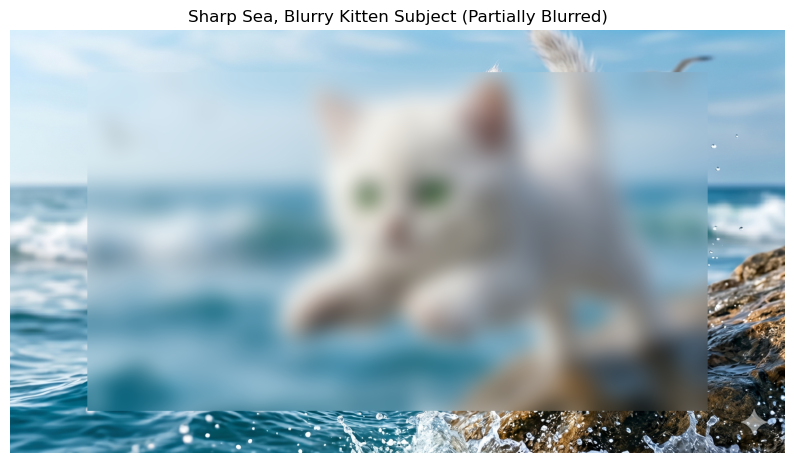

In [31]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# [1. 재료 가져오기]
# [설명] 원본 사진을 작업대 위로 올립니다.
cat_rgb = cv2.cvtColor(cv2.imread("cat.png"), cv2.COLOR_BGR2RGB)

# [안전장치] 만약 'cat.png'가 없으면 에러 메시지를 띄우고 종료합니다.
if cat_rgb is None:
    print("❌ 에러: 'cat.png' 파일을 찾을 수 없습니다! 이름을 다시 확인해주세요.")
    print("📂 현재 폴더의 진짜 파일들:", os.listdir())
else:
    # [2. 블러 캔버스 만들기]
    # [영어 번역] blur: 흐리게 하다.
    # [설명] 전체 이미지를 아주 강력하게 흐릿하게 만듭니다. 나중에 오려낼 재료입니다.
    cat_blurred_whole = cv2.GaussianBlur(cat_rgb, (255, 255), 0)

    # [3. 가위질 도안(마스크) 만들기]
    # [영어 번역] zeros: 0(검은색)으로 채우기 / uint8: 8비트 정수 (색상값용)
    # [설명] 고양이가 있는 자리를 흰색(1), 배경을 검은색(0)으로 칠한 도안입니다.
    #       (여기서는 일단 고양이 자리에 큰 사각형을 그릴게요. 나중엔 AI가 땁니다!)
    mask = np.zeros(cat_rgb.shape[:2], np.uint8)
    # [설명] 사각형을 그립니다. (50,50)부터 전체크기보다 조금 작게 그립니다.
    cv2.rectangle(mask, (int(cat_rgb.shape[1]*0.1), int(cat_rgb.shape[0]*0.1)), 
                  (int(cat_rgb.shape[1]*0.9), int(cat_rgb.shape[0]*0.9)), 255, -1)

    # [4. 시공 - 오려내기]
    # [영어 번역] bitwise_and: 비트끼리 '그리고' / mask: 도안
    # [설명] 흐릿하게 만든 캔버스에서 도안(마스크)의 흰색 부분만 싹둑 오려냅니다.
    # [부호] mask=mask : "이 도안의 흰색 부분만 가져와!"라는 뜻입니다.
    cat_blurred_only = cv2.bitwise_and(cat_blurred_whole, cat_blurred_whole, mask=mask)

    # [5. 시공 - 배경 준비]
    # [영어 번역] bitwise_not: 비트 뒤집기 (반전)
    # [설명] 원본 선명한 이미지에서 '고양이 자리'만 검게 구멍을 뚫어야 합니다. 
    #       그래서 도안의 흰색/검은색을 뒤집습니다.
    mask_inv = cv2.bitwise_not(mask)
    cat_sharp_bg_only = cv2.bitwise_and(cat_rgb, cat_rgb, mask=mask_inv)

    # [6. 시공 - 합치기]
    # [영어 번역] add: 더하다 (얹다)
    # [설명] 구멍 뚫린 선명한 배경 위에 흐릿한 고양이 오려낸 걸 단순히 더해서(add) 합칩니다.
    final_art = cv2.add(cat_sharp_bg_only, cat_blurred_only)

    # [7. 결과 전시]
    # [설명] 깔끔하게 제목을 달아 결과물을 보여줍니다.axis('off')로 자(ruler) 눈금은 숨깁니다.
    plt.figure(figsize=(10, 10))
    plt.imshow(final_art)
    plt.title("Sharp Sea, Blurry Kitten Subject (Partially Blurred)")
    plt.axis('off')
    plt.show()

In [ ]:
import cv2  # (Computer Vision) 컴퓨터 시각 전문 공구 가져오기
import numpy as np  # (Numerical Python) 수학 및 행렬 전문 도구 가져오기

# 1. 원본 이미지 가져오기
# [해석] variable_original_image = cv2(공구) + im(image) + read(읽다) + "cat.png"(파일이름)
original_image = cv2.imread("cat.png")  # (원본 그림 가져오기)

# [안전장치] 만약 'cat.png'가 없으면 에러 메시지를 띄우고 종료합니다.
if original_image is None:
    print("❌ 에러: 'cat.png' 파일을 찾을 수 없습니다! 이름을 다시 확인해주세요.")
else:
    # 2. 아주 강력하게 블러 처리된 '블러 캔버스' 만들기
    # [해석] variable_blurred_image = cv2(공구) + GaussianBlur(블러 페인트 칠하기) + (original_image, (101, 101), 0)
    # [설명] (101, 101)은 '블러 붓의 크기'입니다. 큰 홀수여야 아주 흐릿해집니다.
    blurred_image = cv2.GaussianBlur(original_image, (101, 101), 0)  # (전체 블러 캔버스)

    # 3. '스탠실 도안(마스크)' 만들기
    # [해석] variable_mask = np(수학 도구) + zeros_like(같은 크기의 빈 도화지 만들기) + original_image
    mask = np.zeros_like(original_image)  # (전체 검은색 도안)

    # [설명] 아티스트님이 그리신 붉은 영역을 사각형으로 가정하고, 흰색으로 칠합니다.
    #       (세로시작:세로끝, 가로시작:가로끝) 형식으로 좌표를 지정합니다.
    # [주의] 이 좌표는 예시이며, 실제 이미지 크기에 맞게 조절해야 합니다.
    # [설명] mask[50픽셀에서:750픽셀까지, 50픽셀에서:950픽셀까지] = (R:255, G:255, B:255)
    mask[50:750, 50:950] = (255, 255, 255)  # (블러 영역을 흰색으로 칠하기)

    # 4. 합성 및 시공: 스탠실 도안을 써서 흐릿한 부분만 가져오기
    # [해석] variable_result_image = np(수학 도구) + where(만약 ~라면) + (mask가 흰색인 곳, blurred_image를, 그렇지 않으면 original_image를)
    # [설명] 로봇에게 말합니다: "스탠실 도안이 흰색인 곳은 블러 캔버스를 쓰고, 검은색인 곳은 선명한 원본을 써!"
    result_image = np.where(mask == (255, 255, 255), blurred_image, original_image)  # (합성된 최종 결과물)

    # 5. 결과 전시하기
    # [해석] cv2(공구) + imshow(이미지 보여주기) + "ResultWindow"(창 이름), result_image(그림 이름)
    cv2.imshow("Original Image", original_image)  # 원본 창 열기
    cv2.imshow("Mask Stencil", mask)  # 스탠실 도안 창 열기
    cv2.imshow("Final Result with Partial Blur", result_image)  # 결과 창 열기

    # 6. 전시 유지 및 청소
    # [해석] cv2(공구) + waitKey(키 기다리기) + (0)
    cv2.waitKey(0)  # 아무 키나 누를 때까지 기다리기 (창을 유지합니다)
    cv2.destroyAllWindows()  # (청소) 열려있는 모든 전시 창 닫기

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt # 웹 전시장 도구 가져오기

# 1. 재료 가져오기
# [해석] 그림을 읽어온 뒤, 컴퓨터 눈(BGR)을 우리 눈(RGB)에 맞게 안경을 씌워줍니다.
img_bgr = cv2.imread("cat.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

if img_rgb is None:
    print("❌ 파일을 찾을 수 없어요!")
else:
    # 2. 아주 흐릿한 '블러 캔버스' 만들기
    # [설명] (255, 255)는 아주 두꺼운 불투명 시트지라고 생각하세요!
    blurred_img = cv2.GaussianBlur(img_rgb, (255, 255), 0)

    # 3. '스탠실 도안(마스크)' 만들기
    # [설명] 아티스트님이 그린 빨간 영역만큼 흰색으로 칠할 도화지입니다.
    mask = np.zeros_like(img_rgb)
    
    # [좌표 설정] 아티스트님이 표시한 고양이 위치에 맞춰서 사각형을 그립니다.
    # [형식] mask[세로시작:세로끝, 가로시작:가로끝] = (흰색)
    # 이미지 크기에 따라 이 숫자를 조금씩 조절해보세요!
    mask[150:600, 200:700] = (255, 255, 255) 

    # 4. 합성하기 (로봇에게 시키는 명령)
    # [해석] 도안이 흰색(255)인 곳은 '흐릿한 그림'을 쓰고, 아니면 '선명한 그림'을 써!
    final_result = np.where(mask == (255, 255, 255), blurred_img, img_rgb)

    # 5. 전시장(plt)에 안전하게 결과 보여주기
    plt.figure(figsize=(12, 8))
    plt.imshow(final_result)
    plt.title("Partial Blur Success!")
    plt.axis('off') # 눈금 자 숨기기
    plt.show()